# Data Loading

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch

from notebooks.config import Config
from notebooks.dataloaders.gnn_data_loader import GNNDataLoader
from notebooks.models.hetero_GAT import HeteroGAT
from utils import visualize_graph
from utils import get_edge_predictions

In [ ]:
# Load model outputs

# Scenarios
case_study = 'manhattan_case_study'
results_dir = os.path.join('..', 'studies', case_study, 'results')
scenario_names = [
    'test_manhattan_scenario_1',
    'test_manhattan_scenario_2',
    'test_manhattan_scenario_3',
]

scenarios = [os.path.join(results_dir, sc) for sc in scenario_names]

# Create config with shorter simulation duration for testing
config = Config(
    sim_start=0,
    sim_end=1800
)

loader = GNNDataLoader(scenarios, config, overwrite=False)
data, *masks = loader.load_data()

Processing scenarios: 100%|██████████| 3/3 [00:00<00:00, 57.76it/s]


In [3]:
num_classes = 1  # Binary classification - single output logit with sigmoid activation
hidden_channels = 32  # Size of hidden layers in GNN
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HeteroGAT(hidden_channels, num_classes).to(device=device)

MODEL_PATH = 'data/models/best_model.pt'

if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])

In [4]:
edge_preds = []
for graph_idx in range(len(data)):
    edge_preds.append(get_edge_predictions(data, graph_idx=graph_idx, model=model, device=device))

# Input EDA

In [5]:
# Quick stats
total_edges = sum([data[graph_idx].num_edges for graph_idx in range(len(data))])
print(f"Total number of edges: {total_edges}")
print(f"Number of graphs (time steps): {len(data)}")
print(f"Average number of edges per graph: {total_edges / len(data):.2f}")
print(f"Average number of nodes per type:")
for node_type in set(node_type for graph in data for node_type in graph.x_dict):
    num_nodes = sum(data[graph_idx][node_type].num_nodes for graph_idx in range(len(data))) / len(data)
    print(f" - {node_type}: {num_nodes:.2f}")

Total number of edges: 79874
Number of graphs (time steps): 180
Average number of edges per graph: 443.74
Average number of nodes per type:
 - vehicle: 120.00
 - request: 28.47


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0, 0.5, 'Number of Requests')

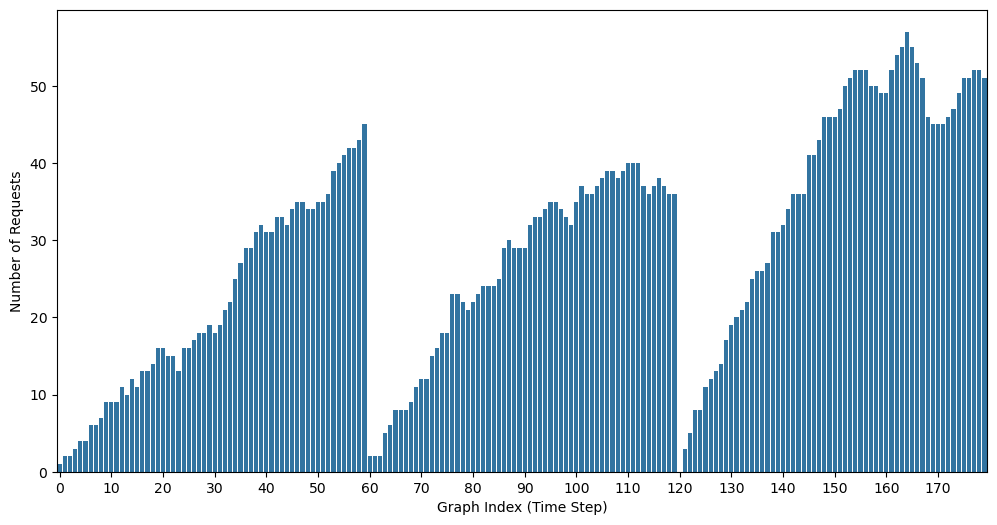

In [6]:
# Plot number of requests per graph
num_requests_per_graph = [len(graph.x_dict['request']) for graph in data]
# sns.boxplot(x=num_requests_per_graph)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(range(len(num_requests_per_graph))), y=num_requests_per_graph)
plt.xticks(ticks=list(range(0, len(num_requests_per_graph), 10)));
plt.xlabel('Graph Index (Time Step)')
plt.ylabel('Number of Requests')

In [7]:
# Node degree distributions

# Output EDA

torch.Size([0, 1])
torch.Size([25, 1])
Graph: 0 Source node: 2 from edge type: ('vehicle', 'connects', 'request')
Node edges: tensor([0])
Node labels: tensor([0])
Node scores: tensor([[0.4148]])
Sorted indices: tensor([[0]])
Optimal positions: tensor([], dtype=torch.int64)
Graph: 0 Source node: 3 from edge type: ('vehicle', 'connects', 'request')
Node edges: tensor([0])
Node labels: tensor([0])
Node scores: tensor([[0.5583]])
Sorted indices: tensor([[0]])
Optimal positions: tensor([], dtype=torch.int64)
Graph: 0 Source node: 6 from edge type: ('vehicle', 'connects', 'request')
Node edges: tensor([0])
Node labels: tensor([0])
Node scores: tensor([[0.3756]])
Sorted indices: tensor([[0]])
Optimal positions: tensor([], dtype=torch.int64)
Graph: 0 Source node: 10 from edge type: ('vehicle', 'connects', 'request')
Node edges: tensor([0])
Node labels: tensor([0])
Node scores: tensor([[0.4124]])
Sorted indices: tensor([[0]])
Optimal positions: tensor([], dtype=torch.int64)
Graph: 0 Source node

/var/folders/tw/f3j1pqdj5wz0kzj6_tpd5vbc0000gn/T/ipykernel_31585/2044713107.py:60: RuntimeWarning: invalid value encountered in divide
  percentile_ranks = (rankings / (num_edges - 1)) * 100  # convert to percentile


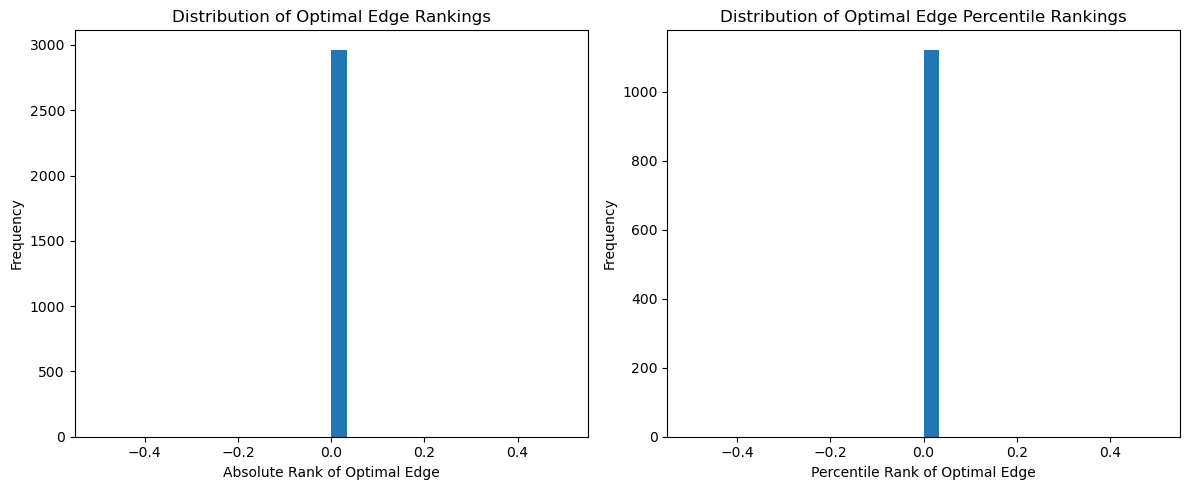

In [12]:
import numpy as np

def analyze_edge_rankings(data, edge_preds):
    rankings = []
    num_edges = []
    
    for graph_idx in range(len(data)):
        graph = data[graph_idx]
        preds = torch.tensor(edge_preds[graph_idx])  # Convert to torch tensor
        
        # Get edge indices for each node type combination
        edge_index_dict = graph.edge_index_dict
        edge_label_dict = graph.y_dict
        
        # Track the offset for each edge type
        offset = 0
        
        # For each edge type
        for edge_type in edge_index_dict.keys():            
            # Get edges and their predictions
            edges = edge_index_dict[edge_type]
            labels = edge_label_dict[edge_type].squeeze()
            num_edges_this_type = len(labels)
            edge_scores = preds[offset:offset + num_edges_this_type]
            
            # Flatten edge scores if they're 2D
            if edge_scores.dim() > 1:
                edge_scores = edge_scores.squeeze(-1)
            
            # Update offset for next edge type
            offset += num_edges_this_type
            
            # For each unique source node
            for src_node in torch.unique(edges[0]):
                # Get all edges from this source node
                mask = edges[0] == src_node
                node_edges = edges[1][mask]
                node_scores = edge_scores[mask]
                node_labels = labels[mask]
                print('Graph:', graph_idx, 'Source node:', src_node.item(), 'from edge type:', edge_type)
                print('Node edges:', node_edges)
                print('Node labels:', node_labels)
                print('Node scores shape:', node_scores.shape)
                print('Node scores:', node_scores)

                if len(node_edges) > 0:
                    # Sort edges by predicted scores
                    sorted_indices = torch.argsort(node_scores, descending=True)
                    print('Sorted indices:', sorted_indices)
                    # Find where the optimal edge (label=1) is in the sorted list
                    optimal_positions = torch.where(node_labels[sorted_indices] == 1)[0]
                    print('Optimal positions:', optimal_positions)

                    if len(optimal_positions) > 0:  # if there is an optimal edge
                        rankings.append(optimal_positions[0].item())
                        num_edges.append(len(node_edges))

    return np.array(rankings), np.array(num_edges)

# Calculate rankings
rankings, num_edges = analyze_edge_rankings(data, edge_preds)

# Calculate statistics
percentile_ranks = (rankings / (num_edges - 1)) * 100  # convert to percentile

print("Statistics for optimal edge rankings:")
print(f"Mean rank: {rankings.mean():.2f}")
print(f"Median rank: {np.median(rankings):.2f}")
print(f"Mean percentile rank: {percentile_ranks.mean():.2f}%")
print(f"Median percentile rank: {np.median(percentile_ranks):.2f}%")

# Plot distribution of rankings
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(rankings, bins=30)
plt.xlabel('Absolute Rank of Optimal Edge')
plt.ylabel('Frequency')
plt.title('Distribution of Optimal Edge Rankings')

plt.subplot(1, 2, 2)
plt.hist(percentile_ranks, bins=30)
plt.xlabel('Percentile Rank of Optimal Edge')
plt.ylabel('Frequency')
plt.title('Distribution of Optimal Edge Percentile Rankings')

plt.tight_layout()

INFO:utils:Adding true edge: vehicle_11 -> request_0
INFO:root:Visualizing graph 0 with 26 nodes and 25 edges.
INFO:root:True edges: 1, Predicted edges: 25
INFO:root:Hard predicted edges: 1 / 1


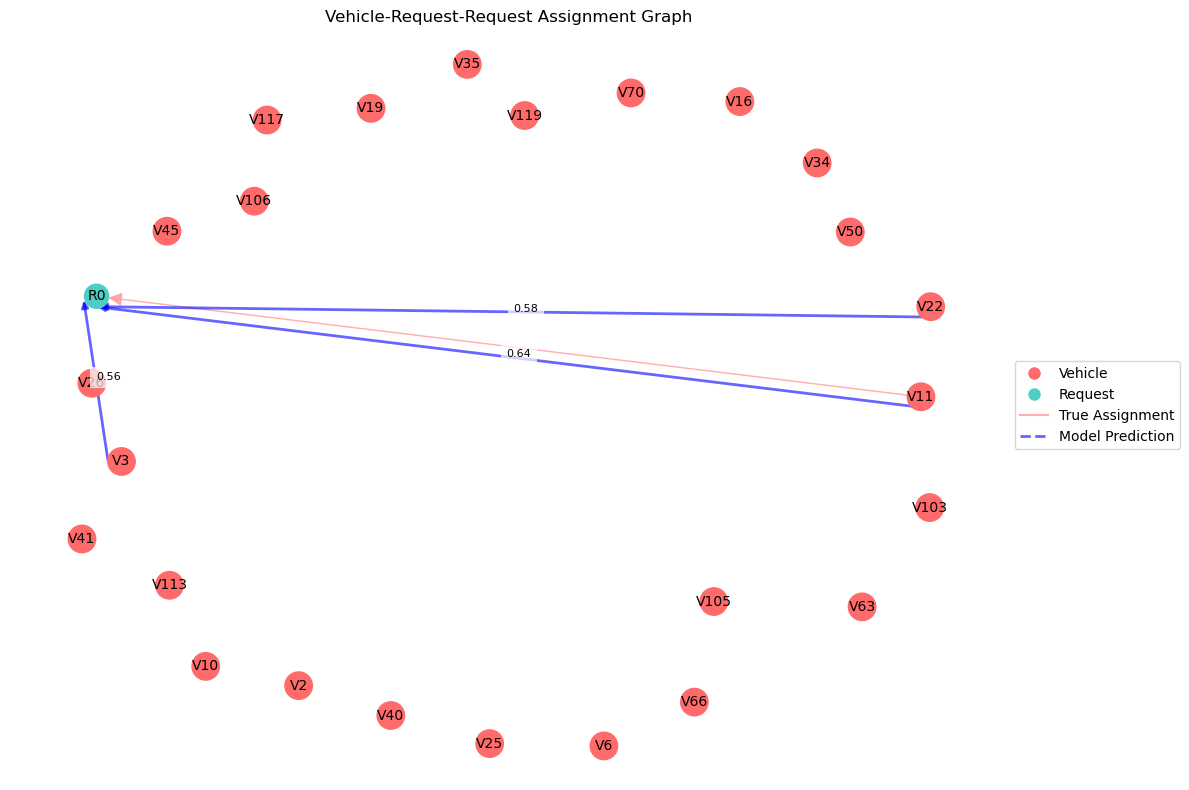

<Figure size 1000x800 with 0 Axes>

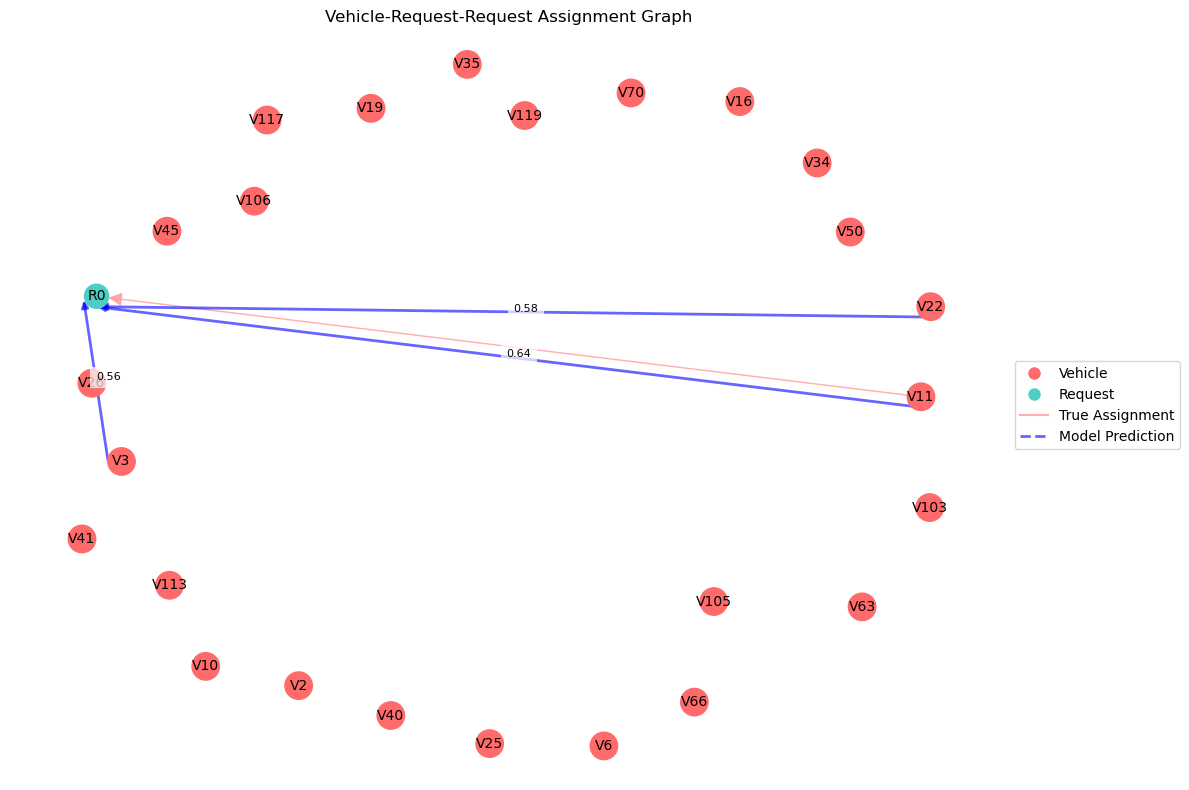

In [10]:
visualize_graph(data, 0, model, device=device)